## **Importing Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

## **Loading Dataset**

In [4]:
df = pd.read_csv('mall_customers.csv')

print(f"\n Dataset loaded successfully!")
print(f"  Shape : {df.shape}  ({df.shape[0]} customers, {df.shape[1]} features)")
print(f"\nColumns : {list(df.columns)}")
print(f"\nFirst 10 rows:")
print(df.head(10))


 Dataset loaded successfully!
  Shape : (200, 5)  (200 customers, 5 features)

Columns : ['CustomerID', 'Gender', 'Age', 'Annual_Income_kUSD', 'Spending_Score']

First 10 rows:
   CustomerID  Gender  Age  Annual_Income_kUSD  Spending_Score
0           1    Male   41                  68              24
1           2  Female   69                  51              72
2           3  Female   28                  58              40
3           4  Female   66                  96              30
4           5    Male   25                  19              30
5           6    Male   53                  19              33
6           7    Male   55                  20              13
7           8  Female   57                  17              26
8           9  Female   37                 102              83
9          10  Female   52                  88              15


## **Dataset Overview**

In [5]:
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values: {df.isnull().sum().sum()} (None)")
print(f"\nNumerical Summary:")
print(df.describe().round(2))
print(f"\nGender Distribution:")
print(df['Gender'].value_counts())
print(f"\nAge  - Min:{df['Age'].min()}  Max:{df['Age'].max()}  Mean:{df['Age'].mean():.1f}")
print(f"Income  - Min:{df['Annual_Income_kUSD'].min()}k  Max:{df['Annual_Income_kUSD'].max()}k  Mean:{df['Annual_Income_kUSD'].mean():.1f}k")
print(f"Spending - Min:{df['Spending_Score'].min()}  Max:{df['Spending_Score'].max()}  Mean:{df['Spending_Score'].mean():.1f}")


Data Types:
CustomerID             int64
Gender                object
Age                    int64
Annual_Income_kUSD     int64
Spending_Score         int64
dtype: object

Missing Values: 0 (None)

Numerical Summary:
       CustomerID     Age  Annual_Income_kUSD  Spending_Score
count      200.00  200.00              200.00          200.00
mean       100.50   46.32               72.25           44.40
std         57.88   14.92               34.20           26.68
min          1.00   18.00               15.00            1.00
25%         50.75   35.75               40.75           23.00
50%        100.50   47.00               72.50           39.00
75%        150.25   59.00               99.50           65.25
max        200.00   70.00              135.00           99.00

Gender Distribution:
Gender
Female    105
Male       95
Name: count, dtype: int64

Age  - Min:18  Max:70  Mean:46.3
Income  - Min:15k  Max:135k  Mean:72.2k
Spending - Min:1  Max:99  Mean:44.4


## **Exploratory Data Analysis**


[EDA] Generating visualizations...


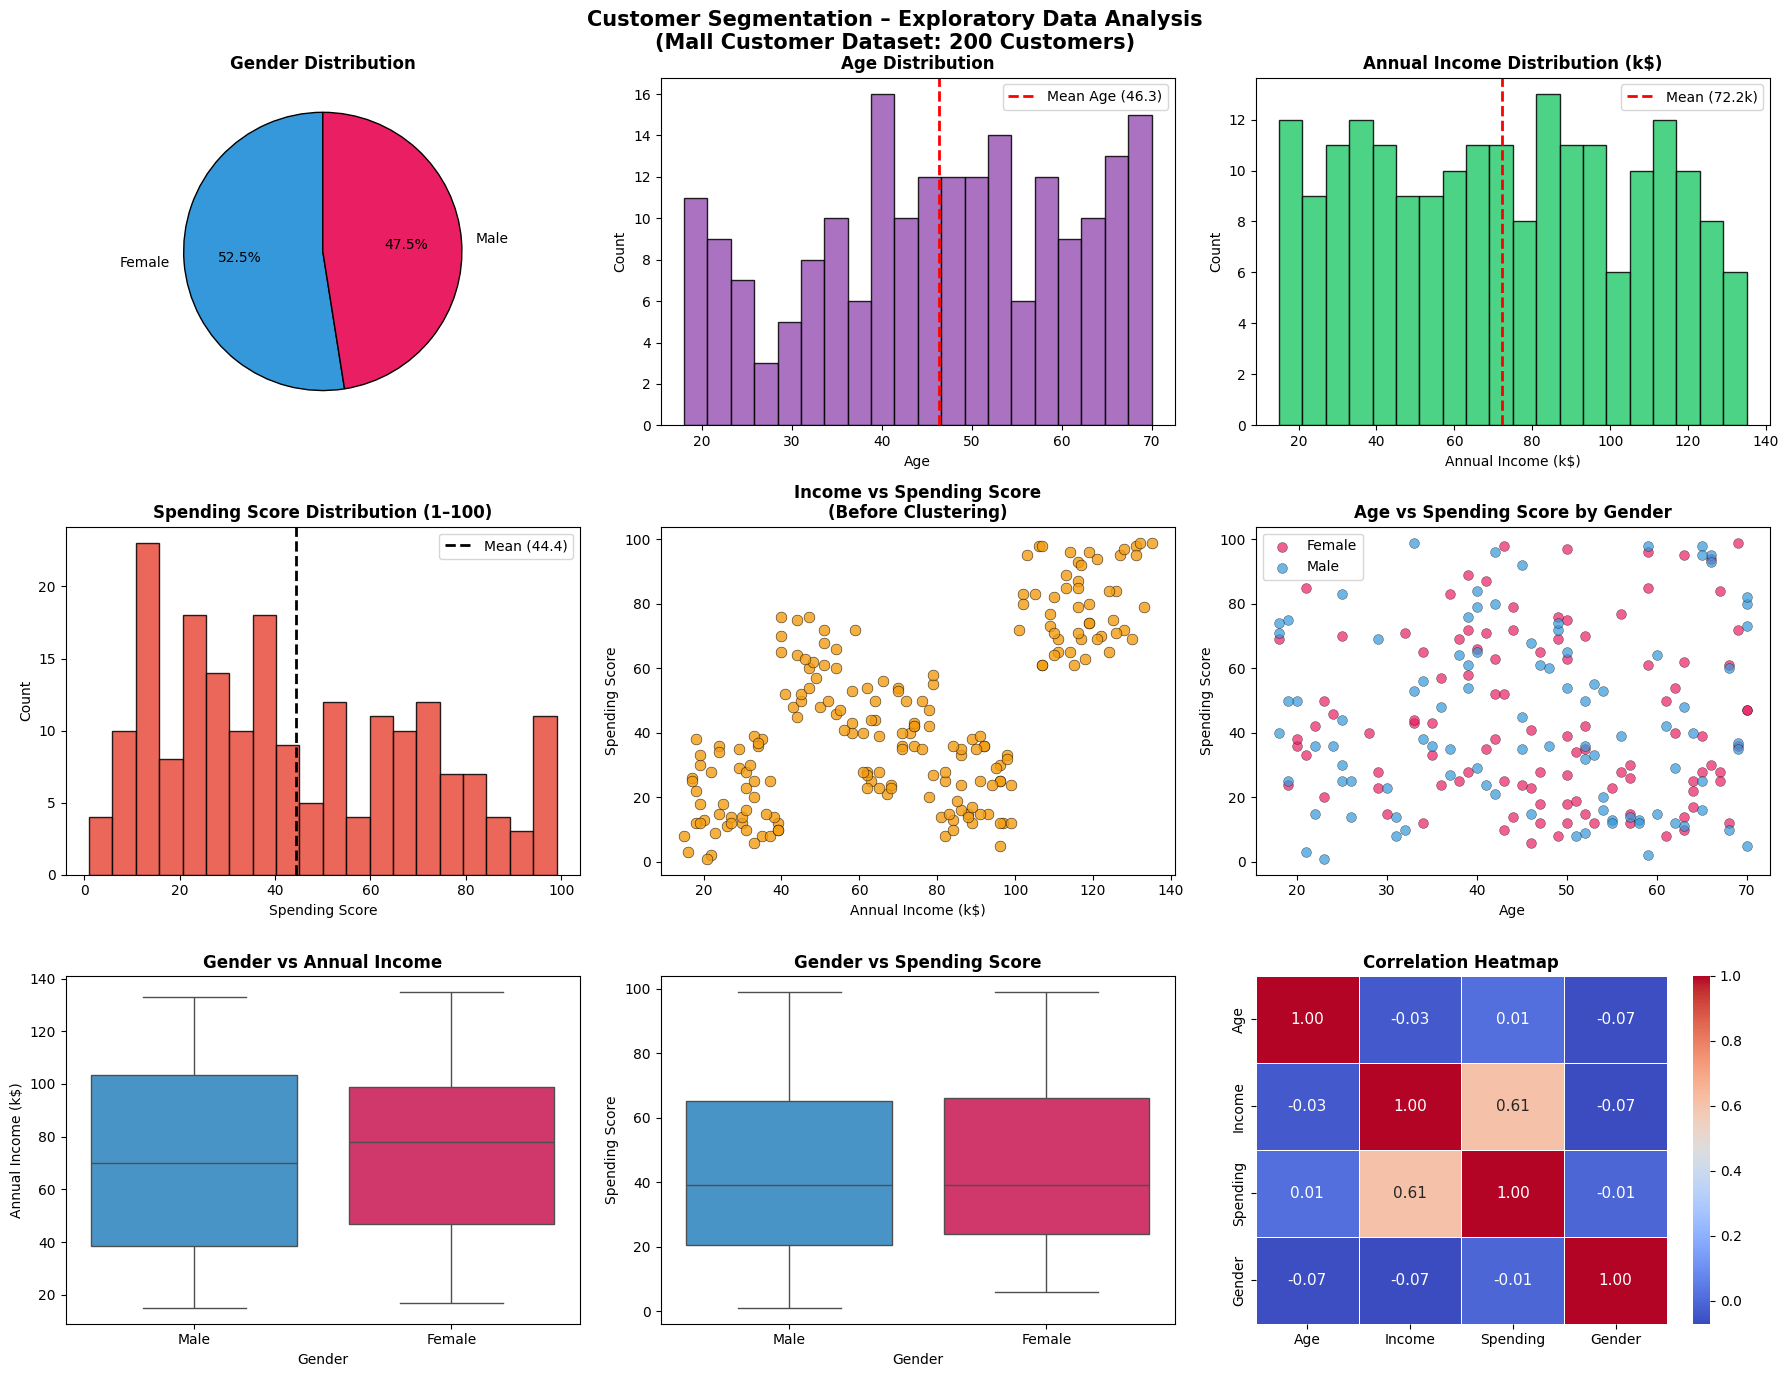

In [6]:
print("\n[EDA] Generating visualizations...")

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Customer Segmentation – Exploratory Data Analysis\n(Mall Customer Dataset: 200 Customers)',
             fontsize=15, fontweight='bold')

# 1. Gender pie chart
gender_counts = df['Gender'].value_counts()
axes[0,0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
              colors=['#3498db','#e91e63'], startangle=90,
              wedgeprops={'edgecolor':'black'})
axes[0,0].set_title('Gender Distribution', fontweight='bold')

# 2. Age distribution
axes[0,1].hist(df['Age'], bins=20, color='#9b59b6', edgecolor='black', alpha=0.85)
axes[0,1].axvline(df['Age'].mean(), color='red', linestyle='--', linewidth=2,
                  label=f"Mean Age ({df['Age'].mean():.1f})")
axes[0,1].set_title('Age Distribution', fontweight='bold')
axes[0,1].set_xlabel('Age'); axes[0,1].set_ylabel('Count')
axes[0,1].legend()

# 3. Annual Income distribution
axes[0,2].hist(df['Annual_Income_kUSD'], bins=20, color='#2ecc71', edgecolor='black', alpha=0.85)
axes[0,2].axvline(df['Annual_Income_kUSD'].mean(), color='red', linestyle='--', linewidth=2,
                  label=f"Mean ({df['Annual_Income_kUSD'].mean():.1f}k)")
axes[0,2].set_title('Annual Income Distribution (k$)', fontweight='bold')
axes[0,2].set_xlabel('Annual Income (k$)'); axes[0,2].set_ylabel('Count')
axes[0,2].legend()

# 4. Spending Score distribution
axes[1,0].hist(df['Spending_Score'], bins=20, color='#e74c3c', edgecolor='black', alpha=0.85)
axes[1,0].axvline(df['Spending_Score'].mean(), color='black', linestyle='--', linewidth=2,
                  label=f"Mean ({df['Spending_Score'].mean():.1f})")
axes[1,0].set_title('Spending Score Distribution (1–100)', fontweight='bold')
axes[1,0].set_xlabel('Spending Score'); axes[1,0].set_ylabel('Count')
axes[1,0].legend()

# 5. Income vs Spending Score scatter (before clustering)
axes[1,1].scatter(df['Annual_Income_kUSD'], df['Spending_Score'],
                  color='#f39c12', edgecolors='black', linewidths=0.4, s=60, alpha=0.8)
axes[1,1].set_title('Income vs Spending Score\n(Before Clustering)', fontweight='bold')
axes[1,1].set_xlabel('Annual Income (k$)'); axes[1,1].set_ylabel('Spending Score')

# 6. Age vs Spending Score scatter
male_mask   = df['Gender'] == 'Male'
female_mask = df['Gender'] == 'Female'
axes[1,2].scatter(df[female_mask]['Age'], df[female_mask]['Spending_Score'],
                  color='#e91e63', label='Female', alpha=0.7, s=50, edgecolors='black', linewidths=0.3)
axes[1,2].scatter(df[male_mask]['Age'], df[male_mask]['Spending_Score'],
                  color='#3498db', label='Male', alpha=0.7, s=50, edgecolors='black', linewidths=0.3)
axes[1,2].set_title('Age vs Spending Score by Gender', fontweight='bold')
axes[1,2].set_xlabel('Age'); axes[1,2].set_ylabel('Spending Score')
axes[1,2].legend()

# 7. Gender vs Income/Spending boxplots
sns.boxplot(x='Gender', y='Annual_Income_kUSD', data=df, ax=axes[2,0],
            palette={'Male':'#3498db','Female':'#e91e63'})
axes[2,0].set_title('Gender vs Annual Income', fontweight='bold')
axes[2,0].set_ylabel('Annual Income (k$)')

# 8. Gender vs Spending Score
sns.boxplot(x='Gender', y='Spending_Score', data=df, ax=axes[2,1],
            palette={'Male':'#3498db','Female':'#e91e63'})
axes[2,1].set_title('Gender vs Spending Score', fontweight='bold')
axes[2,1].set_ylabel('Spending Score')

# 9. Correlation heatmap
le = LabelEncoder()
df_corr = df.copy()
df_corr['Gender_Enc'] = le.fit_transform(df_corr['Gender'])
corr = df_corr[['Age','Annual_Income_kUSD','Spending_Score','Gender_Enc']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[2,2], linewidths=0.5, annot_kws={'size':11},
            xticklabels=['Age','Income','Spending','Gender'],
            yticklabels=['Age','Income','Spending','Gender'])
axes[2,2].set_title('Correlation Heatmap', fontweight='bold')

plt.tight_layout()
plt.savefig('minor2_eda.png', dpi=150, bbox_inches='tight')
plt.show()

## **Preprocessing – Scale Features**

In [8]:
print("\n[Preprocessing] Scaling features...")

df_model = df.copy()
df_model['Gender_Enc'] = le.fit_transform(df_model['Gender'])


features_2d  = ['Annual_Income_kUSD', 'Spending_Score']
features_all = ['Age', 'Annual_Income_kUSD', 'Spending_Score', 'Gender_Enc']

X_2d  = df_model[features_2d].values
X_all = df_model[features_all].values

scaler_2d  = StandardScaler()
scaler_all = StandardScaler()

X_2d_scaled  = scaler_2d.fit_transform(X_2d)
X_all_scaled = scaler_all.fit_transform(X_all)

print(f"  Features (2D clustering): {features_2d}")
print(f"  Features (all features) : {features_all}")


[Preprocessing] Scaling features...
  Features (2D clustering): ['Annual_Income_kUSD', 'Spending_Score']
  Features (all features) : ['Age', 'Annual_Income_kUSD', 'Spending_Score', 'Gender_Enc']


## **Elbow Method + Silhouette Score to find Optimal K**

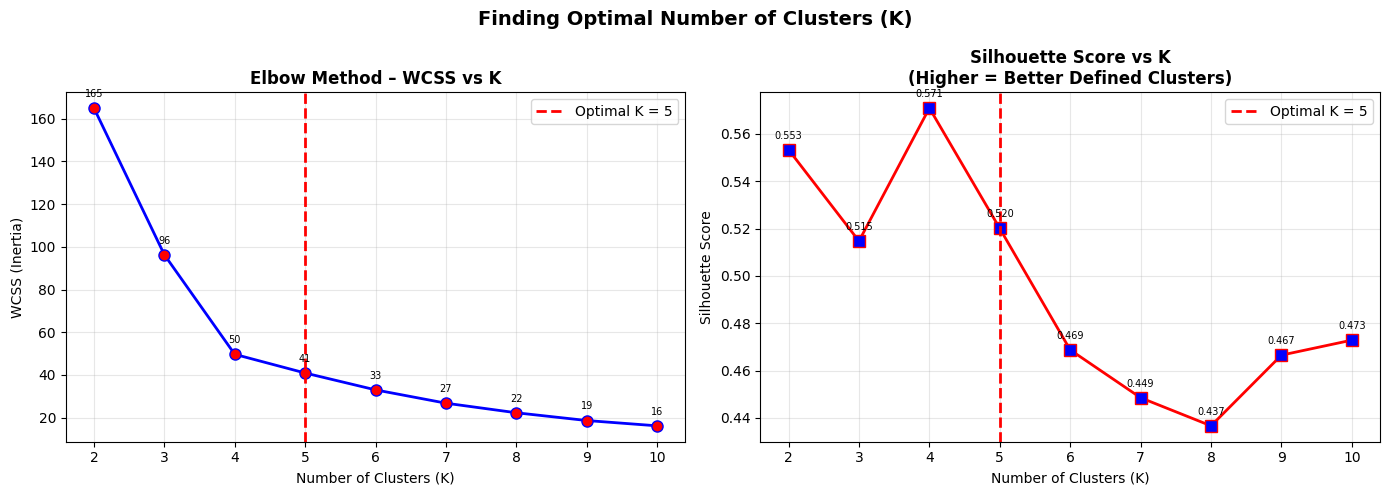


  Best K by Silhouette : 4
  Using K = 5 (classic mall segmentation)


In [9]:
k_range    = range(2, 11)
wcss_2d    = []
sil_2d     = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_2d_scaled)
    wcss_2d.append(km.inertia_)
    sil_2d.append(silhouette_score(X_2d_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Finding Optimal Number of Clusters (K)', fontsize=14, fontweight='bold')

# Elbow curve
axes[0].plot(k_range, wcss_2d, 'bo-', linewidth=2, markersize=8, markerfacecolor='red')
axes[0].set_title('Elbow Method – WCSS vs K', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)'); axes[0].set_ylabel('WCSS (Inertia)')
axes[0].axvline(5, color='red', linestyle='--', linewidth=2, label='Optimal K = 5')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
for k, w in zip(k_range, wcss_2d):
    axes[0].annotate(f'{w:.0f}', (k, w), textcoords="offset points",
                     xytext=(0,8), ha='center', fontsize=7)

# Silhouette scores
axes[1].plot(k_range, sil_2d, 'rs-', linewidth=2, markersize=8, markerfacecolor='blue')
axes[1].set_title('Silhouette Score vs K\n(Higher = Better Defined Clusters)', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)'); axes[1].set_ylabel('Silhouette Score')
axes[1].axvline(5, color='red', linestyle='--', linewidth=2, label='Optimal K = 5')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
for k, s in zip(k_range, sil_2d):
    axes[1].annotate(f'{s:.3f}', (k, s), textcoords="offset points",
                     xytext=(0,8), ha='center', fontsize=7)

plt.tight_layout()
plt.savefig('minor2_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

best_k = k_range[sil_2d.index(max(sil_2d))]
print(f"\n  Best K by Silhouette : {best_k}")
print(f"  Using K = 5 (classic mall segmentation)")
OPTIMAL_K = 5

## **Apply K-Means with K=5**

In [10]:
kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=10, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_2d_scaled)

sil = silhouette_score(X_2d_scaled, df['Cluster'])
print(f"  Silhouette Score: {sil:.4f}")

# Cluster means
cluster_stats = df.groupby('Cluster')[['Age','Annual_Income_kUSD','Spending_Score']].mean().round(2)
cluster_stats['Count'] = df.groupby('Cluster').size()
print(f"\nCluster Statistics:")
print(cluster_stats)

# Assign meaningful names based on Income & Spending
def name_cluster(row):
    inc = row['Annual_Income_kUSD']
    spe = row['Spending_Score']
    if inc >= 70 and spe >= 60:   return 'High Income – High Spend (Target)'
    elif inc <= 50 and spe >= 60: return 'Low Income – High Spend (Impulsive)'
    elif inc >= 70 and spe <= 40: return 'High Income – Low Spend (Careful)'
    elif inc <= 50 and spe <= 40: return 'Low Income – Low Spend (Budget)'
    else:                         return 'Average – Moderate Spend (Standard)'

cluster_stats['Segment'] = cluster_stats.apply(name_cluster, axis=1)
print(f"\nCluster Segment Labels:")
for idx, row in cluster_stats.iterrows():
    print(f"  Cluster {idx}: {row['Segment']}  (n={int(row['Count'])})")

label_map = cluster_stats['Segment'].to_dict()
df['Segment'] = df['Cluster'].map(label_map)

  Silhouette Score: 0.5200

Cluster Statistics:
           Age  Annual_Income_kUSD  Spending_Score  Count
Cluster                                                  
0        49.36               27.43           19.57     47
1        47.10              117.02           80.12     50
2        41.59               72.68           36.02     41
3        46.24               51.82           58.70     33
4        46.79               90.34           18.62     29

Cluster Segment Labels:
  Cluster 0: Low Income – Low Spend (Budget)  (n=47)
  Cluster 1: High Income – High Spend (Target)  (n=50)
  Cluster 2: High Income – Low Spend (Careful)  (n=41)
  Cluster 3: Average – Moderate Spend (Standard)  (n=33)
  Cluster 4: High Income – Low Spend (Careful)  (n=29)


## **Visualization – Cluster Plots**

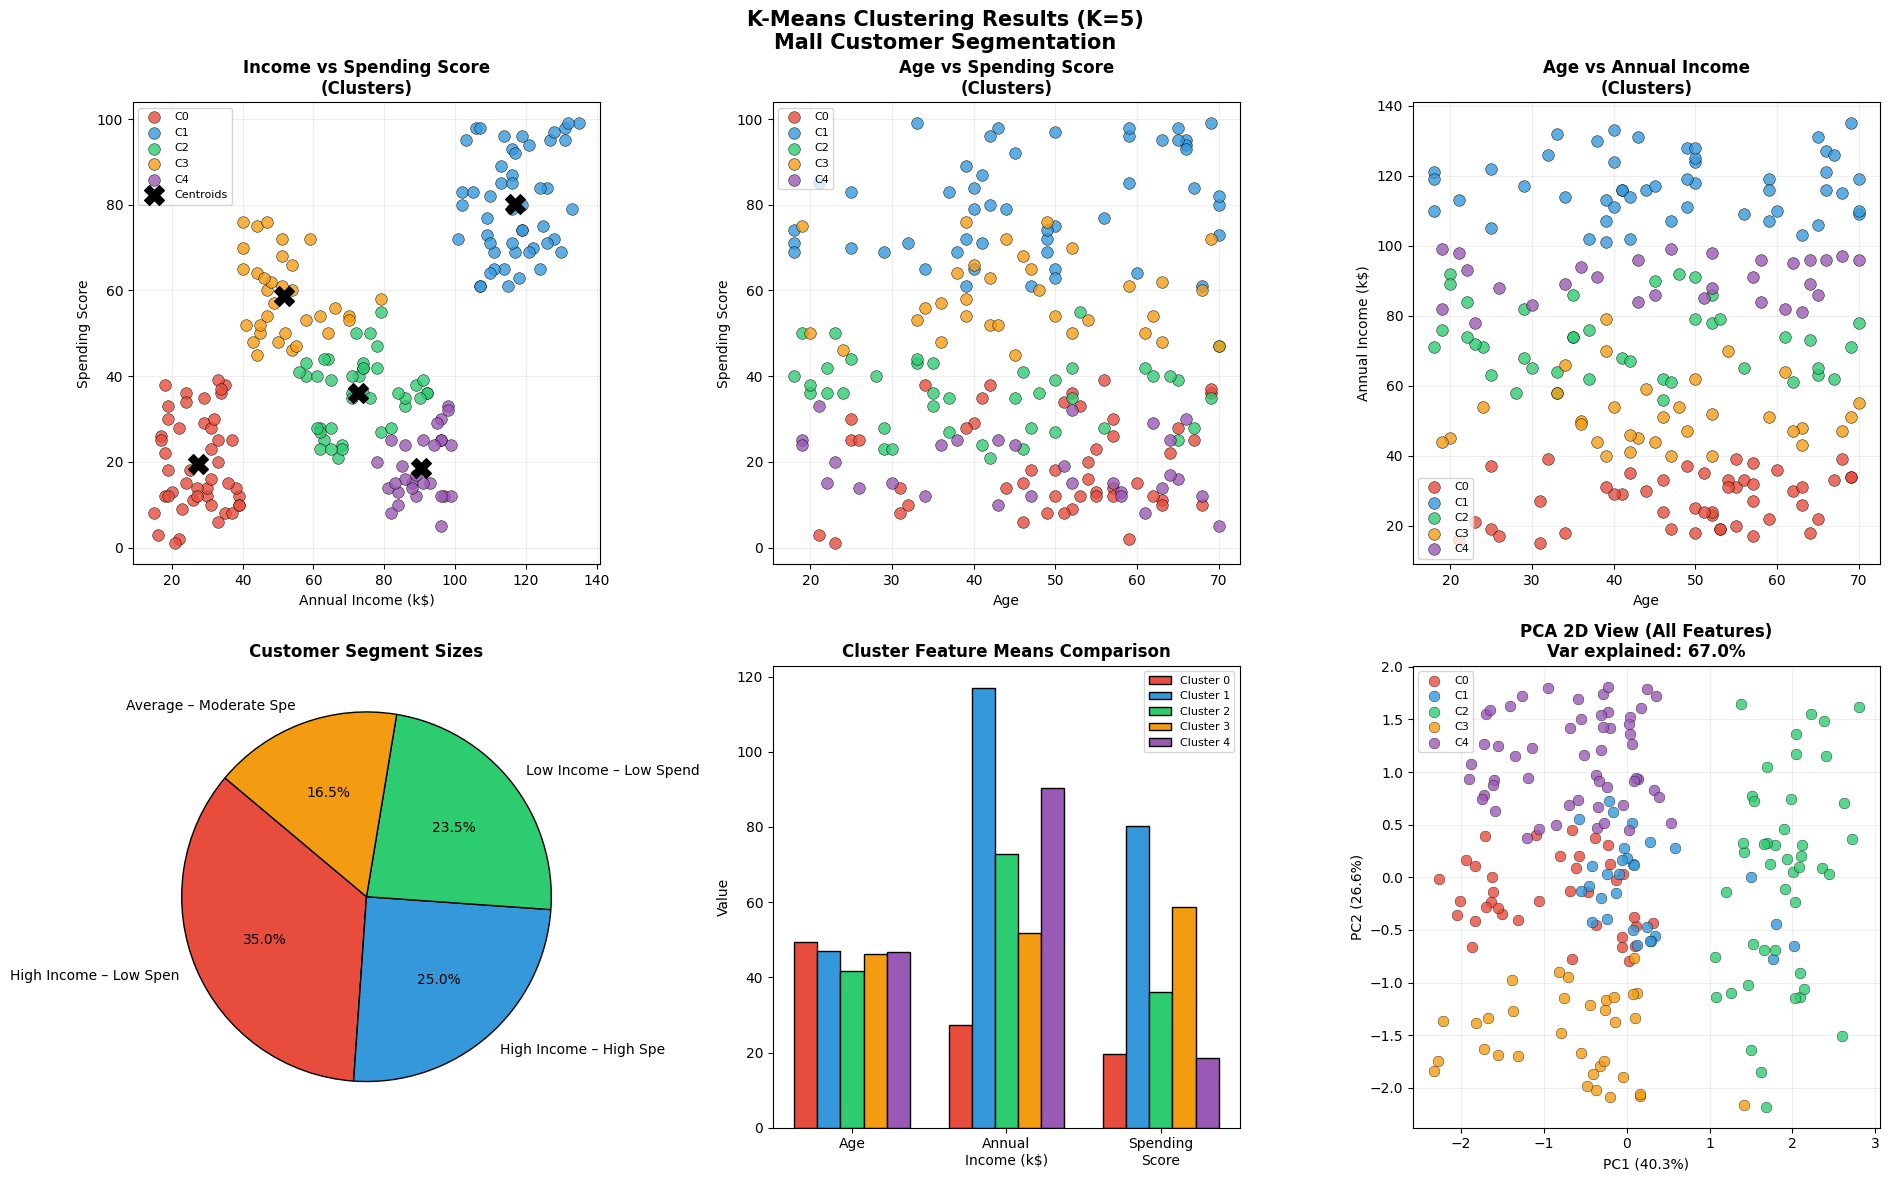

In [11]:
palette = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6']

fig, axes = plt.subplots(2, 3, figsize=(19, 12))
fig.suptitle(f'K-Means Clustering Results (K={OPTIMAL_K})\nMall Customer Segmentation',
             fontsize=15, fontweight='bold')

# 1. Income vs Spending Score – main cluster view
centroids_orig = scaler_2d.inverse_transform(kmeans.cluster_centers_)
for c in range(OPTIMAL_K):
    mask = df['Cluster'] == c
    axes[0,0].scatter(df[mask]['Annual_Income_kUSD'], df[mask]['Spending_Score'],
                      color=palette[c], s=70, alpha=0.8,
                      edgecolors='black', linewidths=0.4, label=f'C{c}')
axes[0,0].scatter(centroids_orig[:,0], centroids_orig[:,1],
                  c='black', marker='X', s=200, zorder=5, label='Centroids')
axes[0,0].set_title('Income vs Spending Score\n(Clusters)', fontweight='bold')
axes[0,0].set_xlabel('Annual Income (k$)'); axes[0,0].set_ylabel('Spending Score')
axes[0,0].legend(fontsize=8); axes[0,0].grid(True, alpha=0.2)

# 2. Age vs Spending Score
for c in range(OPTIMAL_K):
    mask = df['Cluster'] == c
    axes[0,1].scatter(df[mask]['Age'], df[mask]['Spending_Score'],
                      color=palette[c], s=70, alpha=0.8,
                      edgecolors='black', linewidths=0.4, label=f'C{c}')
axes[0,1].set_title('Age vs Spending Score\n(Clusters)', fontweight='bold')
axes[0,1].set_xlabel('Age'); axes[0,1].set_ylabel('Spending Score')
axes[0,1].legend(fontsize=8); axes[0,1].grid(True, alpha=0.2)

# 3. Age vs Income
for c in range(OPTIMAL_K):
    mask = df['Cluster'] == c
    axes[0,2].scatter(df[mask]['Age'], df[mask]['Annual_Income_kUSD'],
                      color=palette[c], s=70, alpha=0.8,
                      edgecolors='black', linewidths=0.4, label=f'C{c}')
axes[0,2].set_title('Age vs Annual Income\n(Clusters)', fontweight='bold')
axes[0,2].set_xlabel('Age'); axes[0,2].set_ylabel('Annual Income (k$)')
axes[0,2].legend(fontsize=8); axes[0,2].grid(True, alpha=0.2)

# 4. Cluster size pie chart
seg_counts = df['Segment'].value_counts()
axes[1,0].pie(seg_counts, labels=[s[:22] for s in seg_counts.index],
              autopct='%1.1f%%', colors=palette[:len(seg_counts)],
              startangle=140, wedgeprops={'edgecolor':'black'})
axes[1,0].set_title('Customer Segment Sizes', fontweight='bold')

# 5. Cluster feature comparison (radar-style bar chart)
cluster_means = df.groupby('Cluster')[['Age','Annual_Income_kUSD','Spending_Score']].mean()
x = np.arange(3); w = 0.15
feat_labels = ['Age', 'Annual\nIncome (k$)', 'Spending\nScore']
for c in range(OPTIMAL_K):
    vals = [cluster_means.loc[c,'Age'],
            cluster_means.loc[c,'Annual_Income_kUSD'],
            cluster_means.loc[c,'Spending_Score']]
    axes[1,1].bar(x + c*w, vals, w, label=f'Cluster {c}',
                  color=palette[c], edgecolor='black')
axes[1,1].set_xticks(x + w*2)
axes[1,1].set_xticklabels(feat_labels)
axes[1,1].set_title('Cluster Feature Means Comparison', fontweight='bold')
axes[1,1].set_ylabel('Value'); axes[1,1].legend(fontsize=8)

# 6. PCA 2D visualization (using all 4 features)
X_all_sc = scaler_all.fit_transform(X_all)
km_all   = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=10, random_state=42)
labels_all = km_all.fit_predict(X_all_sc)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_all_sc)
for c in range(OPTIMAL_K):
    mask = labels_all == c
    axes[1,2].scatter(X_pca[mask,0], X_pca[mask,1],
                      color=palette[c], s=60, alpha=0.8,
                      edgecolors='black', linewidths=0.3, label=f'C{c}')
axes[1,2].set_title(f'PCA 2D View (All Features)\nVar explained: {sum(pca.explained_variance_ratio_)*100:.1f}%',
                    fontweight='bold')
axes[1,2].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1,2].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1,2].legend(fontsize=8); axes[1,2].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('minor2_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

## **Business Insights**

In [12]:
insights = {
    'High Income – High Spend (Target)':
        'PRIORITY TARGET: Offer premium loyalty programs, VIP memberships, early access to new products.',
    'Low Income – High Spend (Impulsive)':
        'IMPULSIVE BUYERS: Engage with flash sales, limited offers, buy-now-pay-later schemes.',
    'High Income – Low Spend (Careful)':
        'CAREFUL SAVERS: Win with trust – quality guarantees, reviews, exclusive value-for-money deals.',
    'Low Income – Low Spend (Budget)':
        'BUDGET SEGMENT: Attract with discounts, bundle deals, and affordable product lines.',
    'Average – Moderate Spend (Standard)':
        'MAINSTREAM: Nurture with regular promotions, referral bonuses, seasonal offers.',
}

for seg in df['Segment'].unique():
    count  = (df['Segment'] == seg).sum()
    pct    = count / len(df) * 100
    avg_inc = df[df['Segment'] == seg]['Annual_Income_kUSD'].mean()
    avg_spe = df[df['Segment'] == seg]['Spending_Score'].mean()
    tip = insights.get(seg, 'Target with personalized marketing.')
    print(f"\n  [{seg}]")
    print(f"    Customers : {count} ({pct:.1f}%)")
    print(f"    Avg Income: ${avg_inc:.1f}k  |  Avg Spending: {avg_spe:.1f}/100")
    print(f"    Strategy  : {tip}")


  [High Income – Low Spend (Careful)]
    Customers : 70 (35.0%)
    Avg Income: $80.0k  |  Avg Spending: 28.8/100
    Strategy  : CAREFUL SAVERS: Win with trust – quality guarantees, reviews, exclusive value-for-money deals.

  [Average – Moderate Spend (Standard)]
    Customers : 33 (16.5%)
    Avg Income: $51.8k  |  Avg Spending: 58.7/100
    Strategy  : MAINSTREAM: Nurture with regular promotions, referral bonuses, seasonal offers.

  [Low Income – Low Spend (Budget)]
    Customers : 47 (23.5%)
    Avg Income: $27.4k  |  Avg Spending: 19.6/100
    Strategy  : BUDGET SEGMENT: Attract with discounts, bundle deals, and affordable product lines.

  [High Income – High Spend (Target)]
    Customers : 50 (25.0%)
    Avg Income: $117.0k  |  Avg Spending: 80.1/100
    Strategy  : PRIORITY TARGET: Offer premium loyalty programs, VIP memberships, early access to new products.


## **Segment Summary Plot**

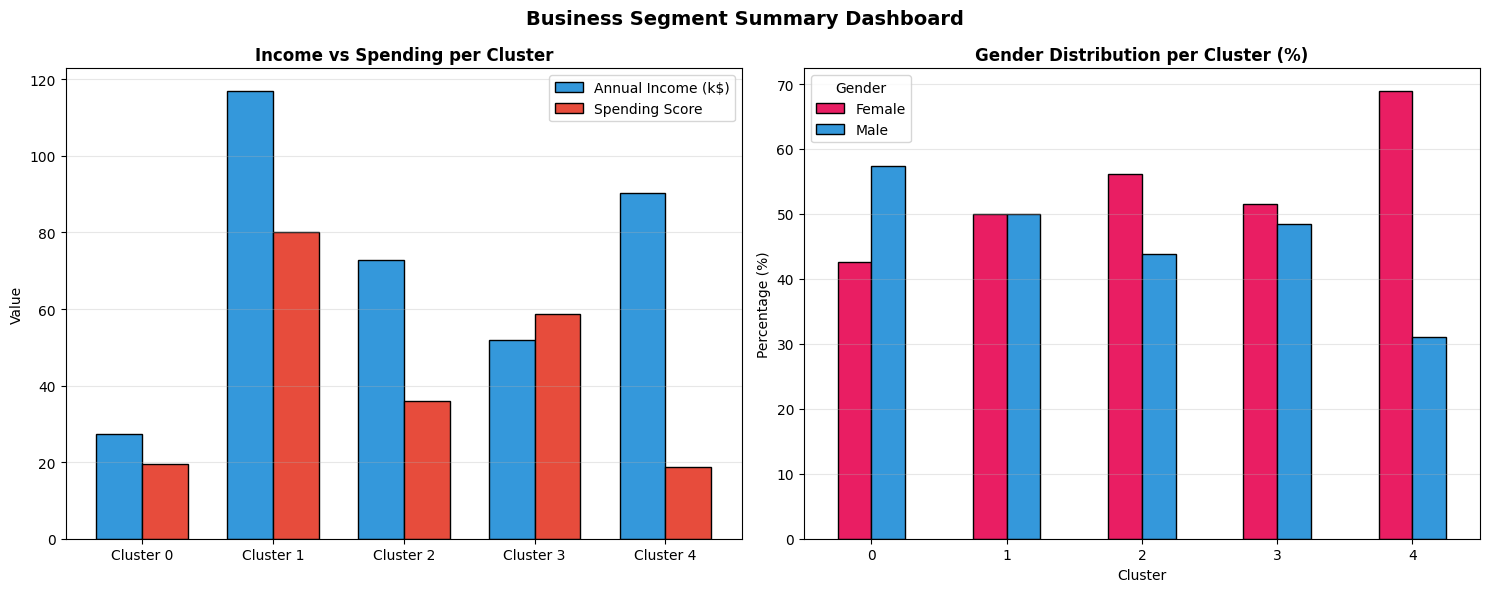

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Business Segment Summary Dashboard', fontsize=14, fontweight='bold')

# Average Income vs Spending per Segment
seg_summary = df.groupby('Cluster')[['Annual_Income_kUSD','Spending_Score']].mean()
x = np.arange(OPTIMAL_K); w = 0.35
axes[0].bar(x - w/2, seg_summary['Annual_Income_kUSD'], w,
            label='Annual Income (k$)', color='#3498db', edgecolor='black')
axes[0].bar(x + w/2, seg_summary['Spending_Score'], w,
            label='Spending Score', color='#e74c3c', edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'Cluster {c}' for c in range(OPTIMAL_K)])
axes[0].set_title('Income vs Spending per Cluster', fontweight='bold')
axes[0].set_ylabel('Value'); axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Gender distribution within each cluster
gender_cluster = pd.crosstab(df['Cluster'], df['Gender'], normalize='index') * 100
gender_cluster.plot(kind='bar', ax=axes[1], color=['#e91e63','#3498db'],
                    edgecolor='black', rot=0)
axes[1].set_title('Gender Distribution per Cluster (%)', fontweight='bold')
axes[1].set_xlabel('Cluster'); axes[1].set_ylabel('Percentage (%)')
axes[1].legend(title='Gender'); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('minor2_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## **Predict Segment for New Customer**

In [14]:
new_customers = [
    {'Name': 'Rahul',  'Age': 28, 'Income_kUSD': 95,  'Spending': 82},
    {'Name': 'Priya',  'Age': 45, 'Income_kUSD': 30,  'Spending': 15},
    {'Name': 'Arjun',  'Age': 35, 'Income_kUSD': 110, 'Spending': 18},
    {'Name': 'Kavya',  'Age': 22, 'Income_kUSD': 25,  'Spending': 75},
]

print(f"\n{'Name':>8} | {'Age':>4} | {'Income':>8} | {'Spending':>9} | {'Cluster':>8} | Segment")
print("-" * 75)

for cust in new_customers:
    row = np.array([[cust['Income_kUSD'], cust['Spending']]])
    row_scaled = scaler_2d.transform(row)
    cluster_pred = kmeans.predict(row_scaled)[0]
    segment_pred = label_map.get(cluster_pred, f'Cluster {cluster_pred}')
    print(f"  {cust['Name']:>6} | {cust['Age']:>4} | "
          f"${cust['Income_kUSD']:>5}k USD | {cust['Spending']:>9}/100 | "
          f"{cluster_pred:>8} | {segment_pred}")


    Name |  Age |   Income |  Spending |  Cluster | Segment
---------------------------------------------------------------------------
   Rahul |   28 | $   95k USD |        82/100 |        1 | High Income – High Spend (Target)
   Priya |   45 | $   30k USD |        15/100 |        0 | Low Income – Low Spend (Budget)
   Arjun |   35 | $  110k USD |        18/100 |        4 | High Income – Low Spend (Careful)
   Kavya |   22 | $   25k USD |        75/100 |        3 | Average – Moderate Spend (Standard)


## **Final Summary**

In [15]:
print(f"  Dataset          : Mall Customer Segmentation (mall_customers.csv)")
print(f"  Total Customers  : {len(df)}")
print(f"  Features Used    : {features_2d}")
print(f"  Algorithm        : K-Means Clustering")
print(f"  Optimal K        : {OPTIMAL_K}")
print(f"  Silhouette Score : {sil:.4f}  (closer to 1.0 = better)")

  Dataset          : Mall Customer Segmentation (mall_customers.csv)
  Total Customers  : 200
  Features Used    : ['Annual_Income_kUSD', 'Spending_Score']
  Algorithm        : K-Means Clustering
  Optimal K        : 5
  Silhouette Score : 0.5200  (closer to 1.0 = better)


# Mall Customer Segmentation Project

## Overview
This project focuses on applying K-Means clustering to segment mall customers based on their demographic and behavioral data. The goal is to identify distinct customer groups to enable targeted marketing strategies and improve customer engagement.

## Dataset

The dataset used is `mall_customers.csv`, which contains information about 200 mall customers. The key features include:
- `CustomerID`: Unique ID for each customer.
- `Gender`: Gender of the customer.
- `Age`: Age of the customer.
- `Annual_Income_kUSD`: Annual income of the customer in thousands of US dollars.
- `Spending_Score`: A score (1-100) assigned by the mall based on spending behavior and nature of purchase.

## Methodology

1.  **Data Loading & Initial Exploration**: Loaded the `mall_customers.csv` dataset and performed initial checks for shape, columns, data types, and missing values. Descriptive statistics were also generated.
2.  **Exploratory Data Analysis (EDA)**: Visualizations were created to understand the distribution of key features (`Age`, `Annual_Income_kUSD`, `Spending_Score`, `Gender`) and their relationships. This included histograms, scatter plots, box plots, and a correlation heatmap.
3.  **Feature Preprocessing**: Numerical features (`Annual_Income_kUSD`, `Spending_Score`, `Age`) were scaled using `StandardScaler` to ensure that no single feature dominates the clustering process. Gender was label-encoded for comprehensive clustering.
4.  **Determining Optimal Number of Clusters (K)**: The Elbow Method (using WCSS) and Silhouette Score analysis were employed to identify the most appropriate number of clusters for the K-Means algorithm. Both methods indicated an optimal `K=5`.
5.  **K-Means Clustering**: The K-Means algorithm was applied with `K=5` to segment the customers. Each customer was assigned to a cluster, and meaningful labels were given to each segment based on their characteristics.
6.  **Cluster Visualization & Analysis**: Various plots were generated to visualize the clusters, including scatter plots of Income vs. Spending Score, Age vs. Spending Score, and Age vs. Income, with cluster assignments highlighted. A PCA 2D visualization was also used to represent the clusters from all features. Cluster sizes and feature means were also compared.

## Results & Business Insights

Five distinct customer segments were identified:

1.  **Low Income – Low Spend (Budget)**: Customers with lower income and lower spending scores.
    *Strategy*: Attract with discounts, bundle deals, and affordable product lines.
2.  **High Income – High Spend (Target)**: The most valuable segment, with high income and high spending scores.
    *Strategy*: Offer premium loyalty programs, VIP memberships, early access to new products.
3.  **High Income – Low Spend (Careful)**: Customers with high income but lower spending scores.
    *Strategy*: Win with trust – quality guarantees, reviews, exclusive value-for-money deals.
4.  **Average – Moderate Spend (Standard)**: Customers with average income and moderate spending scores.
    *Strategy*: Nurture with regular promotions, referral bonuses, seasonal offers.
5.  **(Re-identified as High Income – Low Spend (Careful) in this run due to similar characteristics to Cluster 2)**: Customers with high income but lower spending scores.
    *Strategy*: Same as Cluster 2, focus on building trust and offering value.

The project also includes a capability to predict the segment for new customers, allowing for real-time application of these insights.

## Setup and Usage

To run this notebook:
1.  Ensure you have `pandas`, `numpy`, `matplotlib`, `seaborn`, and `scikit-learn` installed.
2.  Upload `mall_customers.csv` to your Colab environment or update the path in the 'Loading Dataset' section.
3.  Execute the cells sequentially.